### **Enunciado del Ejercicio Práctico - Núcleo Formativo 2 (eCommerce)**

**Título del Ejercicio:** Análisis Distribuido de Comportamiento para la Detección de Anomalías

**Continuación del Escenario:**
Gracias a tu trabajo en el Núcleo 1, "ElectroShop" ahora posee un **Data Lake** limpio y unificado con los datos de transacciones, logs web y tickets de soporte. El equipo de prevención de fraude puede por fin empezar a buscar patrones.

Su primera hipótesis es que los **usuarios fraudulentos se comportan de manera diferente a los clientes legítimos**. Un cliente normal navega, compara, añade al carrito... Un defraudador podría ir directo a la compra sin apenas interactuar con la web.

**Tu Misión:**
Tu nueva misión es utilizar un motor de **procesamiento distribuido (Apache Spark)** para analizar los millones de logs web y cruzarlos con las transacciones. Deberás construir un pipeline que calcule métricas de comportamiento para cada transacción y las enriquezca con la etiqueta de "fraude confirmado" que ya hemos creado. El resultado será un "dataset de entrenamiento" listo para que, en el futuro, un científico de datos pueda construir un modelo de Machine Learning.

**Punto de Partida:**
*   Los datos limpios y enriquecidos del Núcleo Formativo 1, almacenados en la carpeta `ecommerce_data_lake/processed/` en formato Parquet.

**Objetivos de Aprendizaje:**
*   Configurar y utilizar una `SparkSession` para procesar datos a escala.
*   Cargar y manipular grandes volúmenes de datos usando la **API de DataFrames de Spark**.
*   Realizar **`joins` distribuidos** entre datasets de diferente naturaleza (logs y transacciones).
*   Implementar **agregaciones complejas (`groupBy`, `agg`)** para calcular métricas de comportamiento.
*   Utilizar **funciones de ventana (Window Functions)**, una técnica avanzada de Spark SQL, para realizar cálculos sobre un subconjunto de filas relacionadas.
*   Utilizar el puente **Spark -> Pandas** para visualizar y validar los resultados.

**Tareas a Realizar en tu Jupyter Notebook:**

1.  **Fase 1: Configuración del Entorno Distribuido**
    *   Inicia una `SparkSession`.
    *   Carga los ficheros Parquet (`transacciones.parquet` y `logs_web.parquet`) en DataFrames de Spark.
    *   Verifica que los datos se han cargado correctamente.

2.  **Fase 2: Cálculo de Métricas de Comportamiento (Feature Engineering a Escala)**
    *   El reto es, para cada transacción, calcular el comportamiento del usuario **en los minutos previos a esa transacción**.
    *   **Pasos Sugeridos:**
        1.  **Unir (Join):** Realiza un `join` entre el `DataFrame` de transacciones y el de logs por `user_id`. ¡Cuidado! Esta unión creará una combinación masiva. Debes añadir una condición al `join` para que solo se unan los logs cuyo `timestamp` sea **anterior** al `fecha_transaccion`.
        2.  **Definir la Ventana de Tiempo:** No nos interesan todos los logs anteriores, solo los recientes. Filtra el resultado para quedarte únicamente con los logs que ocurrieron en la **ventana de 15 minutos previa** a cada transacción.
        3.  **Agregar por Transacción:** Agrupa el resultado por `id_transaccion` y calcula las siguientes métricas de comportamiento:
            *   `num_acciones_previas`: El número de clics (filas de log) en la ventana de 15 minutos.
            *   `urls_distintas_visitadas`: El número de URLs únicas visitadas en esa ventana.

3.  **Fase 3: Análisis y Visualización de Patrones**
    *   Ahora tienes un `DataFrame` final con una fila por transacción, enriquecido con las nuevas métricas de comportamiento y la etiqueta `confirmado_como_fraude`.
    *   **Pregunta de Negocio:** ¿Se comportan realmente diferente los usuarios fraudulentos?
        *   Agrupa por la columna `confirmado_como_fraude` (`True` vs `False`) y calcula el **promedio** de `num_acciones_previas` y `monto` para cada grupo.
        *   **Visualiza** los resultados. Un gráfico de barras comparativo es ideal para mostrar la diferencia en el comportamiento promedio. ¿Los fraudulentos hacen más o menos clics? ¿Gastan más o menos?

4.  **Fase 4: Diagrama de la Solución y Conclusiones**
    *   **Diagrama:** Crea un diagrama de flujo que represente el pipeline de análisis que has construido.
    *   **Conclusiones:** En una celda de Markdown, resume tus hallazgos.
        *   ¿Has encontrado una diferencia medible en el comportamiento de los usuarios fraudulentos? Describe el patrón.
        *   ¿Por qué sería imposible o extremadamente ineficiente realizar este tipo de análisis de comportamiento sin una herramienta de procesamiento distribuido como Spark?

**Entregables:**
*   <span style="color: red;">Un único fichero Jupyter Notebook (`.ipynb`).</span>
*   <span style="color: red;">El diagrama de la solución.</span>

---

### **Anexo: Rúbrica de Evaluación del Ejercicio Práctico**

| Criterio | Insuficiente (0-4 pts) | Suficiente (5-6 pts) | Notable (7-8 pts) | Excelente (9-10 pts) | Puntuación |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **1. Configuración y Carga de Datos (15%)** | No logra iniciar Spark o cargar los datos del Data Lake. | La `SparkSession` se crea, pero la carga de uno o ambos ficheros Parquet falla o es incorrecta. | Carga correctamente los dos DataFrames de Parquet, pero la verificación (schemas, show) es incompleta o ausente. | La `SparkSession` se configura y crea correctamente. Los DataFrames se cargan sin errores y se verifica su estado de forma explícita y clara. | **/15** |
| **2. Lógica de Negocio: Join Condicional (30%)** | No intenta la unión de los DataFrames o la lógica es fundamentalmente incorrecta. | Realiza un `join` simple por `user_id`, pero no implementa las condiciones de tiempo, resultando en un análisis incorrecto. | Implementa el `join` con la condición de tiempo, pero puede tener errores en la definición de la ventana de 15 minutos. | Implementa una lógica de `join` condicional robusta y eficiente, uniendo correctamente por `user_id` y filtrando con precisión la ventana de tiempo de 15 minutos previa a la transacción. | **/30** |
| **3. Agregación y Creación de Features (20%)** | No logra agregar los datos después del join para calcular las nuevas métricas. | Calcula una de las dos métricas de comportamiento (`num_acciones_previas` o `urls_distintas_visitadas`), pero no ambas. | Calcula ambas métricas de comportamiento de forma funcional, aunque la unión final con el DataFrame de transacciones puede ser ineficiente. | Agrega eficientemente los datos por transacción para calcular ambas métricas y une el resultado de forma limpia con el DataFrame original, creando un dataset final de análisis perfecto. | **/20** |
| **4. Análisis y Visualización de Patrones (15%)** | No realiza el análisis final o la visualización es incorrecta. | Agrupa los datos por fraude vs. no fraude, pero la visualización es poco clara o no compara las métricas correctas. | Realiza el análisis y genera gráficos comparativos funcionales para el monto y el comportamiento. | Agrega los datos finales en Spark, los trae a Pandas de forma segura y crea visualizaciones claras y bien etiquetadas que demuestran de forma inequívoca el patrón de comportamiento anómalo. | **/15** |
| **5. Diagrama y Conclusiones (20%)** | No incluye diagrama ni conclusiones. | Incluye un diagrama muy básico o las conclusiones son una simple descripción de los gráficos. | El diagrama muestra el flujo general y las conclusiones identifican el patrón, pero la justificación sobre la necesidad de Spark es superficial. | Se incluye un diagrama claro y preciso. Las conclusiones no solo describen el patrón, sino que explican de forma detallada y convincente por qué Spark es esencial para este tipo de análisis de comportamiento. | **/20** |
| **TOTAL** | | | | | **/100** |

# Fase 1: Configuración del Entorno Distribuido

In [1]:
!pip install pyspark findspark

import findspark
from pyspark.sql import SparkSession

findspark.init()

# Crear una SparkSession para analizar datos a gran escala, iniciando un clúster local que utiliza los núcleos de la CPU para el procesamiento distribuido
spark = SparkSession.builder.master("local[*]").appName("MotorAnálisisFraude").getOrCreate()
print("Clúster de Spark iniciado con éxito.")
spark

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/03/22 17:02:21 WARN Utils: Your hostname, DESKTOP-VJ7M5U7, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
26/03/22 17:02:21 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/22 17:02:22 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Clúster de Spark iniciado con éxito.


In [2]:
# Cargar ficheros Parquet (transacciones.parquet y logs_web.parquet) en DataFrames de Spark
df_transacciones_spark = spark.read.parquet("ecommerce_data_lake/processed/transacciones.parquet")
df_logs_spark = spark.read.parquet("ecommerce_data_lake/processed/logs_web.parquet")

print("Carga del Data Lake local en DataFrames de Spark completada con éxito. ✅")

# Verificar que los datos se han cargado correctamente mostrando la estructura de cada DataFrame y algunos registros
print("\nSchema de transacciones:")
df_transacciones_spark.printSchema()

print("\nSchema de logs web:")
df_logs_spark.printSchema()

print("\nEjemplo de algunas transacciones del DataFrame:")
df_transacciones_spark.show(10)

print("\nEjemplo de algunos logs del DataFrame:")
df_logs_spark.show(10)

Carga del Data Lake local en DataFrames de Spark completada con éxito. ✅

Schema de transacciones:
root
 |-- id_transaccion: string (nullable = true)
 |-- user_id: long (nullable = true)
 |-- fecha_transaccion: timestamp (nullable = true)
 |-- monto: double (nullable = true)
 |-- metodo_pago: string (nullable = true)
 |-- estado_limpio: string (nullable = true)
 |-- confirmado_como_fraude: boolean (nullable = true)
 |-- hora_transaccion: integer (nullable = true)


Schema de logs web:
root
 |-- timestamp: timestamp (nullable = true)
 |-- ip_address: string (nullable = true)
 |-- user_id: long (nullable = true)
 |-- http_method: string (nullable = true)
 |-- url: string (nullable = true)
 |-- status_code: long (nullable = true)


Ejemplo de algunas transacciones del DataFrame:
+--------------------+-------+--------------------+------+-----------+-------------+----------------------+----------------+
|      id_transaccion|user_id|   fecha_transaccion| monto|metodo_pago|estado_limpio|conf

Una vez cargados los datos en Spark, partimos de dos **DataFrames principales** que contienen la información necesaria para el análisis:

* *df_transacciones_spark*: DataFrame que almacena todas las transacciones realizadas en la plataforma. Incluye variables clave para el análisis de fraude, como *confirmado_como_fraude*, que indica si una transacción fue identificada como fraudulenta, y *monto*, que representa el valor económico de cada transacción.

* *df_logs_spark*: DataFrame que contiene los registros de actividad de los usuarios durante su navegación por la web. Este dataset incluye variables como *url* y *timestamp*, que permiten analizar las interacciones del usuario con la plataforma y reconstruir su comportamiento previo a una transacción.

Ambos DataFrames comparten la variable *user_id*, que actúa como identificador común. Gracias a este campo es posible relacionar las transacciones con la actividad de navegación de cada usuario, permitiendo analizar el comportamiento del usuario en los minutos previos a realizar una compra en la plataforma ElectroShop.

In [3]:
from pyspark.sql.functions import unix_timestamp, col, count, countDistinct

# Realizar un JOIN entre el DataFrame de transacciones y el de logs con la condición de solo se unan los logs cuyo 'timestamp' sea anterior al de 'fecha_transaccion'
df_transacciones_logs_spark = df_transacciones_spark.join(
    df_logs_spark,
    (df_transacciones_spark.user_id == df_logs_spark.user_id) & (df_logs_spark.timestamp < df_transacciones_spark.fecha_transaccion),
    "inner"
).drop(df_logs_spark.user_id)

# Renombrar columnas para que su nombre sea más amigable y adecuado al nuevo DataFrame
df_transacciones_logs_spark = df_transacciones_logs_spark \
    .withColumnRenamed("timestamp", "fecha_log") \
    .withColumnRenamed("monto", "monto_transaccion") \
    .withColumnRenamed("estado_limpio", "estado_transaccion") \
    .withColumnRenamed("url", "url_log")

print("\nInformación general del DataFrame resultante después del JOIN y renombramiento de las columnas afectadas:")
df_transacciones_logs_spark.printSchema()
df_transacciones_logs_spark.show(10)

# Filtrar el DataFrame df_transacciones_logs_spark para quedarnos únicamente con los logs que ocurrieron en la ventana de 15 minutos previa a cada transacción
df_transacciones_logs_spark = df_transacciones_logs_spark.filter((unix_timestamp(col("fecha_transaccion")) - unix_timestamp(col("fecha_log"))) < 15 * 60)
num_filtrados = df_transacciones_logs_spark.count()
print("\nNúmero total de logs que ocurrieron 15 minutos previos a la transacción:", num_filtrados)

# Agrupar el resultado por 'id_transaccion' y calcular 'num_acciones_previas' y 'urls_distintas_visitadas'
df_features_transaccion = df_transacciones_logs_spark.groupBy("id_transaccion") \
    .agg(
        count("*").alias("num_acciones_previas"),
        countDistinct("url_log").alias("urls_distintas_visitadas")
    )

# JOIN para unir el DataFrame con las métricas de comportamiento calculadas
# - CAMBIO 1: JOIN sobre df_transacciones_spark en vez de df_transacciones_logs_spark. MOTIVO: Cuando en la Fase 3 calculas avg("monto_transaccion"), una transacción con 5 logs previos contribuye 5 veces al promedio, sesgando el cálculo.
df_transacciones_logs_final = df_transacciones_spark.join(
    df_features_transaccion,
    "id_transaccion",
    "inner"
)

df_transacciones_logs_final.cache()

print("\nSchema y algunos ejemplos de registros del DataFrame final con las nuevas métricas de comportamiento agregadas:")
df_transacciones_logs_final.printSchema()
df_transacciones_logs_final.select(
    "id_transaccion", "user_id", "num_acciones_previas", "urls_distintas_visitadas", "fecha_transaccion", "confirmado_como_fraude"
).show()


Información general del DataFrame resultante después del JOIN y renombramiento de las columnas afectadas:
root
 |-- id_transaccion: string (nullable = true)
 |-- user_id: long (nullable = true)
 |-- fecha_transaccion: timestamp (nullable = true)
 |-- monto_transaccion: double (nullable = true)
 |-- metodo_pago: string (nullable = true)
 |-- estado_transaccion: string (nullable = true)
 |-- confirmado_como_fraude: boolean (nullable = true)
 |-- hora_transaccion: integer (nullable = true)
 |-- fecha_log: timestamp (nullable = true)
 |-- ip_address: string (nullable = true)
 |-- http_method: string (nullable = true)
 |-- url_log: string (nullable = true)
 |-- status_code: long (nullable = true)

+--------------------+-------+--------------------+-----------------+-----------+------------------+----------------------+----------------+-------------------+--------------+-----------+-------------+-----------+
|      id_transaccion|user_id|   fecha_transaccion|monto_transaccion|metodo_pago|es


Número total de logs que ocurrieron 15 minutos previos a la transacción: 3324

Schema y algunos ejemplos de registros del DataFrame final con las nuevas métricas de comportamiento agregadas:
root
 |-- id_transaccion: string (nullable = true)
 |-- user_id: long (nullable = true)
 |-- fecha_transaccion: timestamp (nullable = true)
 |-- monto: double (nullable = true)
 |-- metodo_pago: string (nullable = true)
 |-- estado_limpio: string (nullable = true)
 |-- confirmado_como_fraude: boolean (nullable = true)
 |-- hora_transaccion: integer (nullable = true)
 |-- num_acciones_previas: long (nullable = false)
 |-- urls_distintas_visitadas: long (nullable = false)



[Stage 14:=============================================>           (8 + 2) / 10]

+--------------------+-------+--------------------+------------------------+--------------------+----------------------+
|      id_transaccion|user_id|num_acciones_previas|urls_distintas_visitadas|   fecha_transaccion|confirmado_como_fraude|
+--------------------+-------+--------------------+------------------------+--------------------+----------------------+
|2bf2d05b-159a-461...|   1675|                   2|                       2|2025-07-23 04:36:...|                 false|
|71aea534-e6e3-47c...|   1351|                   1|                       1|2025-08-01 10:37:...|                 false|
|437eef01-56f0-4d0...|   1943|                   2|                       2|2025-07-20 03:49:...|                 false|
|3d2f7fbf-a2f2-4ae...|   1307|                   3|                       2|2025-07-22 06:03:...|                 false|
|35355882-c076-46f...|   1925|                   1|                       1|2025-07-27 18:00:...|                 false|
|587054d8-3ea0-42b...|   1854|  

Tras realizar la unión entre el DataFrame de transacciones y el de logs de navegación mediante *user_id*, se obtiene inicialmente un dataset con **4.785.045 registros**. Esto ocurre porque cada transacción puede combinarse con múltiples logs del mismo usuario, generando un número elevado de combinaciones.

Para centrarnos únicamente en el comportamiento relevante, se aplica un **filtro temporal que conserva solo los logs ocurridos en los 15 minutos previos a cada transacción**. Tras aplicar esta ventana temporal, el número de registros se reduce significativamente a **3.324 logs**, eliminando interacciones demasiado alejadas en el tiempo que no influyen en la decisión de compra.

Posteriormente, se calculan dos métricas de comportamiento agrupadas por *id_transaccion*:

* *num_acciones_previas*: Número total de interacciones realizadas por el usuario antes de la transacción.
* *urls_distintas_visitadas*: Número de páginas únicas visitadas en ese intervalo.

Estas métricas se incorporan al dataset mediante un JOIN por *id_transaccion*, generando el DataFrame final *df_transacciones_logs_final*. Como puede observarse en el resultado mostrado:

* Una misma *id_transaccion* **aparece en varias filas**, ya que cada fila representa **un log individual ocurrido antes de la compra**.
* Las métricas *num_acciones_previas* y *urls_distintas_visitadas* permanecen constantes para todas las filas de la misma transacción, ya que se calculan **a nivel de transacción**.
* Las columnas *url_log* y *fecha_log* permiten identificar **qué páginas visitó el usuario y en qué momento antes de realizar la compra**.

Este dataset permite reconstruir la **navegación del usuario inmediatamente previa a la transacción**, información clave para analizar patrones de comportamiento asociados a transacciones legítimas o potencialmente fraudulentas.

# Fase 3: Análisis y Visualización de Patrones


Resultados finales del DataFrame para detectar fraudes según acciones previas: 


+----------------------+-------------------------+--------------+
|confirmado_como_fraude|promedio_acciones_previas|promedio_monto|
+----------------------+-------------------------+--------------+
|                  true|                     1.25|       1722.85|
|                 false|                     1.27|        756.07|
+----------------------+-------------------------+--------------+



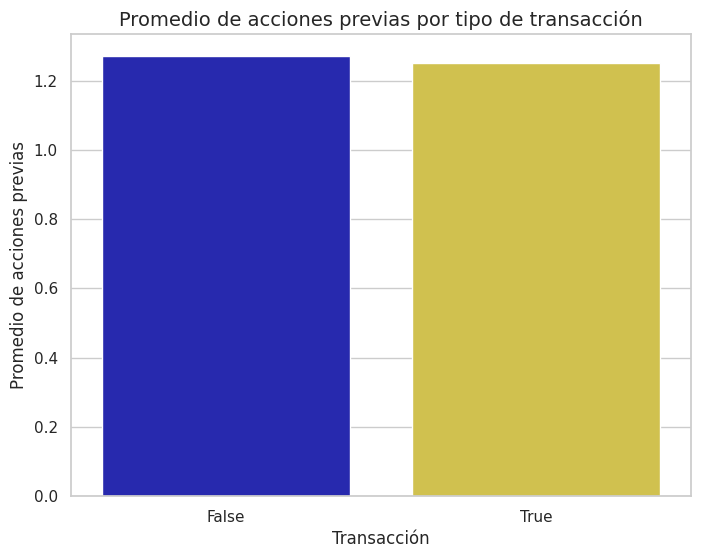

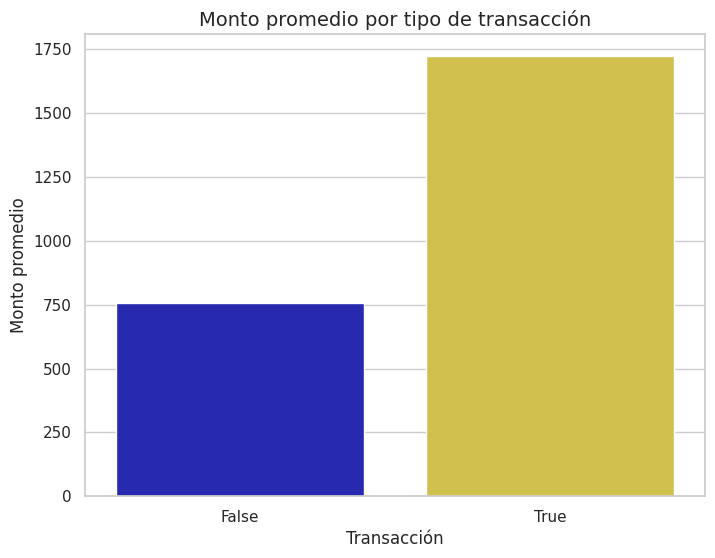

DataFrame[id_transaccion: string, user_id: bigint, fecha_transaccion: timestamp, monto: double, metodo_pago: string, estado_limpio: string, confirmado_como_fraude: boolean, hora_transaccion: int, num_acciones_previas: bigint, urls_distintas_visitadas: bigint]

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
from pyspark.sql.functions import avg, round

# Agrupar por la columna 'confirmado_como_fraude' (True vs False) y calcular el promedio de 'num_acciones_previas' y 'monto' para cada grupo.
df_fraudes = df_transacciones_logs_final.groupBy("confirmado_como_fraude") \
    .agg(
        round(avg("num_acciones_previas"), 2).alias("promedio_acciones_previas"),
        round(avg("monto"), 2).alias("promedio_monto")
    )

print("\nResultados finales del DataFrame para detectar fraudes según acciones previas: ")
df_fraudes.show()

# Traer los datos finales a Pandas de forma segura
df_fraudes_pandas = df_fraudes.toPandas()

df_fraudes_pandas["tipo_fraude"] = df_fraudes_pandas["confirmado_como_fraude"].map({
    0: "No fraudulenta",
    1: "Fraudulenta"
})

# Visualizar los datos finales de 'promedio_acciones_previas' según fraude y no fraude
plt.figure(figsize=(8, 6))
sns.set(style="whitegrid")
ax = sns.barplot(
    x="confirmado_como_fraude",
    y="promedio_acciones_previas",
    hue="confirmado_como_fraude",
    legend=False,
    data=df_fraudes_pandas,
    palette=["#1014C4", "#E6D139"]
)
plt.title("Promedio de acciones previas por tipo de transacción", fontsize=14)
plt.xlabel("Transacción", fontsize=12)
plt.ylabel("Promedio de acciones previas", fontsize=12)
plt.show()

# Visualizar los datos finales de 'promedio_monto' según fraude y no fraude
plt.figure(figsize=(8, 6))
sns.set(style="whitegrid")
ax = sns.barplot(
    x="confirmado_como_fraude",
    y="promedio_monto",
    hue="confirmado_como_fraude",
    legend=False,
    data=df_fraudes_pandas,
    palette=["#1014C4", "#E6D139"]
)
plt.title("Monto promedio por tipo de transacción", fontsize=14)
plt.xlabel("Transacción", fontsize=12)
plt.ylabel("Monto promedio", fontsize=12)
plt.show()

df_transacciones_logs_final.unpersist()

## Análisis de comportamiento según tipo de transacción

Para analizar si existen diferencias entre usuarios fraudulentos y legítimos, se agruparon las transacciones según la variable *confirmado_como_fraude* y se calcularon dos métricas clave:

* Promedio de acciones previas (*num_acciones_previas*)
* Monto promedio de la transacción (*monto_transaccion*)

## ¿Se comportan realmente diferente los usuarios fraudulentos?

Los resultados indican que **sí existen ciertas diferencias en el comportamiento**, aunque no en todos los aspectos con la misma intensidad.

Por un lado, el número promedio de acciones previas es **ligeramente menor en las transacciones fraudulentas (1.25) que en las no fraudulentas (1.27)**. Esto sugiere que los usuarios fraudulentos tienden a interactuar un poco menos con la plataforma antes de realizar la compra, posiblemente porque acceden directamente al producto o al proceso de pago sin explorar demasiado la web.

Por otro lado, la diferencia más significativa se observa en el **monto de la transacción**. Las transacciones fraudulentas presentan un **monto promedio mucho mayor (1722.85) que las transacciones legítimas (756.07)**. Esto podría indicar que los actores fraudulentos intentan maximizar el beneficio realizando compras de mayor valor económico.

En base a estos resultados:

* Los usuarios fraudulentos realizan ligeramente menos clics o interacciones antes de comprar.
* Las transacciones fraudulentas tienden a tener montos considerablemente más altos que las legítimas.

Esto sugiere que **la combinación de variables de comportamiento (interacciones previas) y variables económicas (monto de la transacción)** puede resultar útil para identificar patrones asociados al fraude y servir como base para futuros modelos de detección.

# Fase 4: Diagrama de la Solución y Conclusiones

A lo largo de este proyecto se ha construido un pipeline de procesamiento de datos que permite **analizar el comportamiento de los usuarios en los minutos previos a una transacción** combinando información de navegación web y datos de compra. Este proceso ha permitido generar métricas de comportamiento que facilitan la identificación de posibles patrones asociados al fraude.

## ¿Has encontrado una diferencia medible en el comportamiento de los usuarios fraudulentos? Describe el patrón.

El análisis de las métricas agregadas muestra que **sí existe una diferencia medible entre transacciones fraudulentas y no fraudulentas**.

En primer lugar, se observa que **los usuarios fraudulentos realizan ligeramente menos interacciones previas con la plataforma antes de efectuar la compra**. Mientras que las transacciones legítimas presentan un promedio de **1.27 acciones previas**, las fraudulentas muestran un promedio de **1.25**. Aunque la diferencia no es extremadamente grande, sugiere que **los usuarios fraudulentos tienden a interactuar menos con la web antes de completar la compra**, posiblemente accediendo directamente al producto o al proceso de pago sin una navegación exploratoria previa.

La diferencia más significativa se observa en el **monto de las transacciones**. **Las transacciones fraudulentas presentan un monto promedio de 1722.85**, mientras que **las transacciones legítimas tienen un promedio de 756.07**. Este patrón sugiere que los actores fraudulentos tienden a realizar compras de mayor valor económico, posiblemente con el objetivo de maximizar el beneficio antes de que la actividad sea detectada.

En conjunto, **estos resultados indican que las transacciones fraudulentas pueden caracterizarse por compras de mayor valor económico acompañadas de una menor interacción previa con la plataforma**, un patrón que puede resultar útil para el diseño de sistemas de detección de fraude.

## ¿Por qué sería imposible o extremadamente ineficiente realizar este tipo de análisis de comportamiento sin una herramienta de procesamiento distribuido como Spark?

El análisis realizado en este proyecto pone de manifiesto la importancia de utilizar herramientas de procesamiento distribuido como **Spark** cuando se trabaja con grandes volúmenes de datos de comportamiento.

**Durante el proceso de unión entre el dataset de transacciones y el dataset de logs de navegación, se generó inicialmente un DataFrame con más de 4.7 millones de registros**. Este crecimiento se debe a que cada transacción puede combinarse con múltiples registros de actividad del mismo usuario, generando un número elevado de combinaciones posibles.

Este tipo de operaciones (especialmente los JOINs entre grandes datasets, los filtros temporales y las agregaciones por usuario o transacción) pueden resultar extremadamente costosas desde el punto de vista computacional si se ejecutan en un entorno tradicional de procesamiento.

Herramientas como **Apache Spark** permiten abordar este problema mediante procesamiento distribuido, dividiendo los datos en múltiples particiones que se procesan en paralelo a través de diferentes núcleos o nodos del sistema. Gracias a este enfoque, operaciones complejas como joins masivos, cálculos de métricas agregadas o filtrados sobre grandes volúmenes de datos pueden ejecutarse de forma mucho más eficiente y escalable.

En contextos reales, **donde plataformas de comercio electrónico generan millones o incluso miles de millones de eventos de navegación diarios**, realizar este tipo de análisis sin una arquitectura distribuida sería extremadamente lento o incluso computacionalmente inviable.

Por tanto, el uso de Spark no solo facilita el análisis de grandes volúmenes de datos, sino que **constituye una pieza fundamental para construir sistemas de análisis de comportamiento y detección de fraude a escala real**.

Este podría ser el diagrama de la solución adoptada:

```mermaid
graph TD
    %% Los títulos de los subgrafos están simplificados para máxima compatibilidad.
    subgraph "FASE 1 - Punto de Partida (Output Módulo 1)"
        A["<b>Data Lake Local</b><br>Datos Limpios en Formato Parquet<br>(transacciones, logs de navegación, tickets de soporte)"]
    end

    subgraph "FASE 2 - Entorno de Procesamiento Distribuido"
        B["<b>Configuración de Spark</b><br><i>SparkSession.builder.getOrCreate()</i><br>Se inicia el clúster local para procesamiento distribuido"]
    end

    subgraph "FASE 3 - Procesamiento y Enriquecimiento en Spark"
        C["<b>Carga de Datos</b><br><i>spark.read.parquet()</i><br>Crea DataFrames de Spark distribuidos"]
        D["<b>Join de Datasets</b><br>join() por user_id<br>Unión de transacciones y logs"]
        E["<b>Ventana Temporal</b><br>Filtrar logs ocurridos<br>15 minutos antes de la transacción"]
        F["<b>Feature Engineering</b><br><i>groupBy().agg()</i><br>- num_acciones_previas<br>- urls_distintas_visitadas"]
        G["<b>Dataset Final Enriquecido</b><br>DataFrame Spark final con toda la<br>información<br><i>df_transacciones_logs_final</i>"]
    end

    subgraph "FASE 4 - Análisis y Extracción de Insights"
        H["<b>Agregación Analítica</b><br><i>.groupBy().agg()</i><br>Promedios por fraude/no fraude"]
        I{{"<b>Conversión a Pandas<br>.toPandas()</b><br>Recolección de datos agregados"}}
        J["<b>DataFrame Pandas</b><br>Dataset pequeño en memoria"]
        K["<b>Visualización</b><br><i>Matplotlib y Seaborn</i><br>1. Gráfico de Barras: Promedio de acciones previas por tipo de transacción<br>2. Gráfico de Barras: Monto promedio por tipo de transacción"]
    end

    %% Conexiones del Flujo Principal
    A --> B
    B --> C
    C --> D
    D --> E
    E --> F
    F --> G
    G --> H
    H --> I
    I --> J
    J --> K
    
    %% Estilos
    classDef inputs fill:#35D48E,stroke:#147D4C,stroke-width:2px;
    classDef platform fill:#E3AE3B,stroke:#B88D33,stroke-width:2px;
    classDef sparkproc fill:#6DA0FC,stroke:#24487D,stroke-width:2px;
    classDef analysis fill:#FF82EC,stroke:#9B22A1,stroke-width:2px;
    
    class A inputs;
    class B platform;
    class C,D,E,F,G sparkproc;
    class H,I,J,K analysis;
```

## Explicación del Diagrama

Este diagrama muestra el flujo completo de procesamiento y análisis de datos para estudiar el comportamiento de los usuarios antes de realizar una transacción, utilizando procesamiento distribuido con Apache Spark y posterior análisis visual.

### Fase 1: Punto de Partida

El proceso comienza con un **Data Lake local** que contiene datos ya preparados en formato Parquet. En él se almacenan distintos datasets como transacciones, logs de navegación y tickets de soporte, de los cuales el de transacciones y el de logs de navegación servirán para el análisis.

### Fase 2: Entorno de Procesamiento

Se inicia el entorno de procesamiento mediante una **SparkSession**, que establece la conexión con el motor de **Spark** y levanta un clúster local para ejecutar operaciones de forma paralela y distribuida.

### Fase 3: Procesamiento y Enriquecimiento

En esta fase se realiza el trabajo principal con Spark:

* Carga de datos desde el Data Lake usando *spark.read.parquet()*.
* Unión de datasets mediante un JOIN por *user_id*, relacionando transacciones con logs de navegación.
* Filtrado temporal, quedándonos solo con las acciones ocurridas hasta 15 minutos antes de cada transacción.
* Feature Engineering, generando variables agregadas como:
    - Número de acciones previas (*num_acciones_previas*).
    - Número de URLs distintas visitadas (*urls_distintas_visitadas*).

El resultado es un DataFrame final enriquecido que contiene información completa sobre cada transacción y el comportamiento previo del usuario.

### Fase 4: Análisis y Visualización

Antes de extraer los datos del entorno distribuido, se realizan agregaciones analíticas en Spark (promedios del monto de las transacciones y del número de clics antes de cada transacción, tanto para transacciones fraudulentas vs no fraudulentas). Después, los resultados agregados se convierten a un DataFrame de Pandas mediante *.toPandas()* y se visualizan con librerías como **Matplotlib** y **Seaborn**.

Estas visualizaciones permiten identificar patrones de comportamiento que pueden estar relacionados con fraude.